In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/Student Social Media And Mental Health Impact.csv")
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## Paso 5: Realiza un EDA completo

### Paso 1 EDA: Planteamiento del problema

Buscamos una manera de predecir el nivel de estrés en estudiantes para generarles una alerta temprana a partir hábitos como horas de sueño, tiempo en pantalla de RRSS, horas de actividad física, etc.

Nuestra variable objetivo será: ***'Stress_Level'*** 

### Paso 2 EDA: Exploración y limpieza de datos

In [ ]:
df.shape

(5000, 13)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 736.5 KB


- Nuestro dataframe tiene 5.000 observaciones y 13 variables. Para el modelo de clásificación, vamos a tomar como variable dependiente **'Stress_Level'** y como predictoras todas las restantes. 

- Nuestras variables numéricas son 7: **'Age'**, **'Avg_Daily_Usage_Hours'**, **'Daily_Unlocks'**, **'Study_Hours'**, **'Physical_Activity_Hours'**, **'Sleep_Hours_Per_Night'** y **'Mental_Health_Score '**. 

- Nuestras variables categóricas son 6: **'Gender'**, **'Country'**, **'Academic_Level'**, **'Most_Used_Platform'**, **'Purpose_Of_Use'** y nuestra objetivo **'Stress_Level'**. 

- Por otro lado podemos ver que no hay valores nulos y que el número de filas es de 5.000, que corresponden al número de estudiantes consultados.

Ahora procedemos a analizar si hay duplicados y en su caso, a eliminarlos:

In [ ]:
df.duplicated().sum()

np.int64(2)

Tenemos 2 duplicados. A continuación los eliminaremos.

In [ ]:
if df.duplicated().sum():
    df = df.drop_duplicates()
    
df.shape

(4998, 13)

Luego de eliminar los duplicados, podemos observar que nos quedamos con 4.998 filas.

Ahora nos correspondería eliminar la información irrelevante, pero consideramos que no hay variables irrelevantes para descartar ya que no tenemos identificadores, nombres, etc.

### Paso 3 EDA: Análisis de variables univariante

**Análisis sobre variables categóricas**

In [ ]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

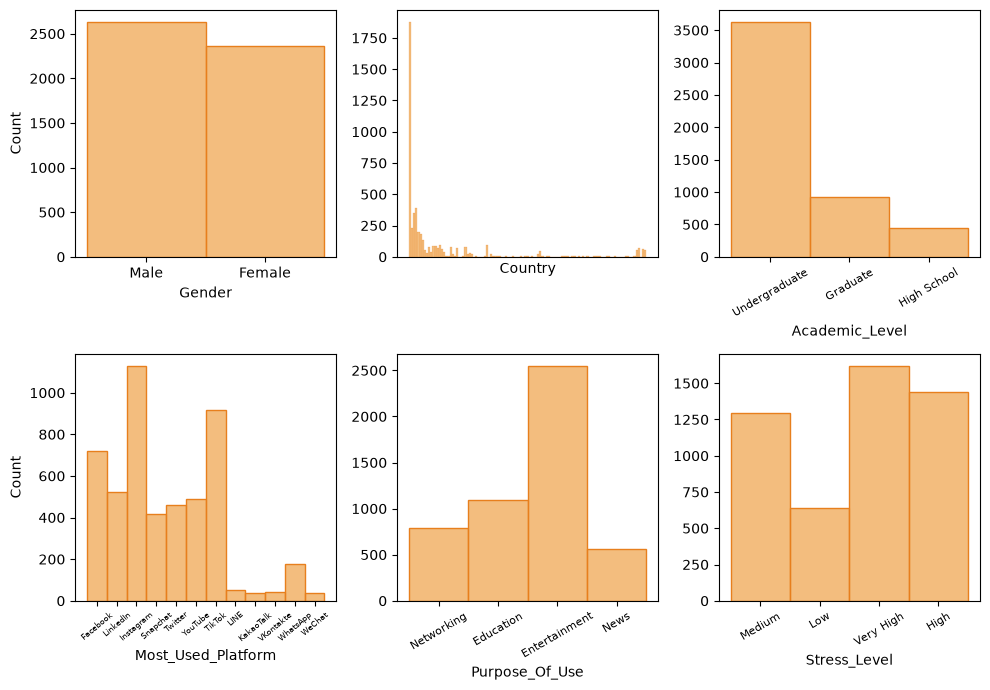

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns

fig, axis = plt.subplots(2, 3, figsize = (10, 7))


sns.histplot(ax = axis[0, 0], data = df, x = "Gender", color="#F0A753", edgecolor="#E77F1D")
sns.histplot(ax = axis[0, 1], data = df, x = "Country", color="#F0A753", edgecolor="#E77F1D").set_xticks([])
axis[0,1].set(ylabel=None)
sns.histplot(ax = axis[0, 2], data = df, x = "Academic_Level", color="#F0A753", edgecolor="#E77F1D").set(ylabel = None)
axis[0,2].tick_params(axis='x', rotation=30, labelsize=8)
sns.histplot(ax = axis[1, 0], data = df, x = "Most_Used_Platform", color="#F0A753", edgecolor="#E77F1D").tick_params(axis='x', rotation=40, labelsize=6)
sns.histplot(ax = axis[1, 1], data = df, x = "Purpose_Of_Use", color="#F0A753", edgecolor="#E77F1D").set(ylabel = None)
axis[1,1].tick_params(axis='x', rotation=30, labelsize=8)
sns.histplot(ax = axis[1, 2], data = df, x = "Stress_Level", color="#F0A753", edgecolor="#E77F1D").set(ylabel = None)
axis[1,2].tick_params(axis='x', rotation=30, labelsize=8)


plt.tight_layout()

plt.show()

Analizando los histogramas anteriores, podemos inferir que:

- El género (**'Gender'**) está bastante balanceado, llevándose la mayoría el género masculino. Esto es muy bueno porque asi nuestro análisis no tiene sesgo de género.

- Existe una fuerte concentración en un solo país principal, con participaciones muy bajas en el resto de los países.

- Predominan elevadamente los estudiantes universitarios no graduados (**'Undergraduated'**), seguidos a gran distancia por estudiantes graduados (**'Graduated'**) y de secundaria (**'High School'**)

- Las RRSS horizontales de entretenimiento centradas en contenido audiovisual se llevan la amplia mayoría, encabezadas por Instagram y TikTok, seguidas por Facebook en tercer lugar. El uso de plataformas de mensajería (LINE, KakaoTalk, WeChat) es la elección mas escasa por los estudiantes.

- La principal motivación para el uso de plataformas es el entretenimiento (**'Entertainment'**), duplicando la suma de usos funcionales como la educación (**'Education'**), la interacción o networking (**'Networking'**) y el consumo de noticias (**'News'**).

- La población analizada nos muestra un nivel de estrés elevado. La gran mayoría de la muestra se ubica en las categorías de estrés Alto (**'High'**) y Muy Alto (**'Very High'** ), mientras que el nivel bajo (**'Low'**) de estrés es la categoría menos representada.

En resumen, los gráficos nos muestran a un grupo mayoritariamente universitario que usa las redes sociales como una vía de escape y entretenimiento visual (Instagram/TikTok), al mismo tiempo que experimenta una alta carga de estrés psicológico o académico. Así mismo, consideramos que la variable que nos muestra el país de residencia (**'Country'**) al estar concentrada fuertemente en un solo país provoca desbalance y al tener tantos valores dispersos, convertirla en variables numéricas solo añade ruido innecesario, aumenta la complejidad del modelo y puede hacer que este falle al intentar predecir con datos nuevos, por lo que la eliminaremos.

In [ ]:
df = df.drop(columns=['Country'])

In [ ]:
df.head()

,Age,Gender,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


**Análisis sobre variables numéricas**

In [ ]:
df.columns

Index(['Age', 'Gender', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

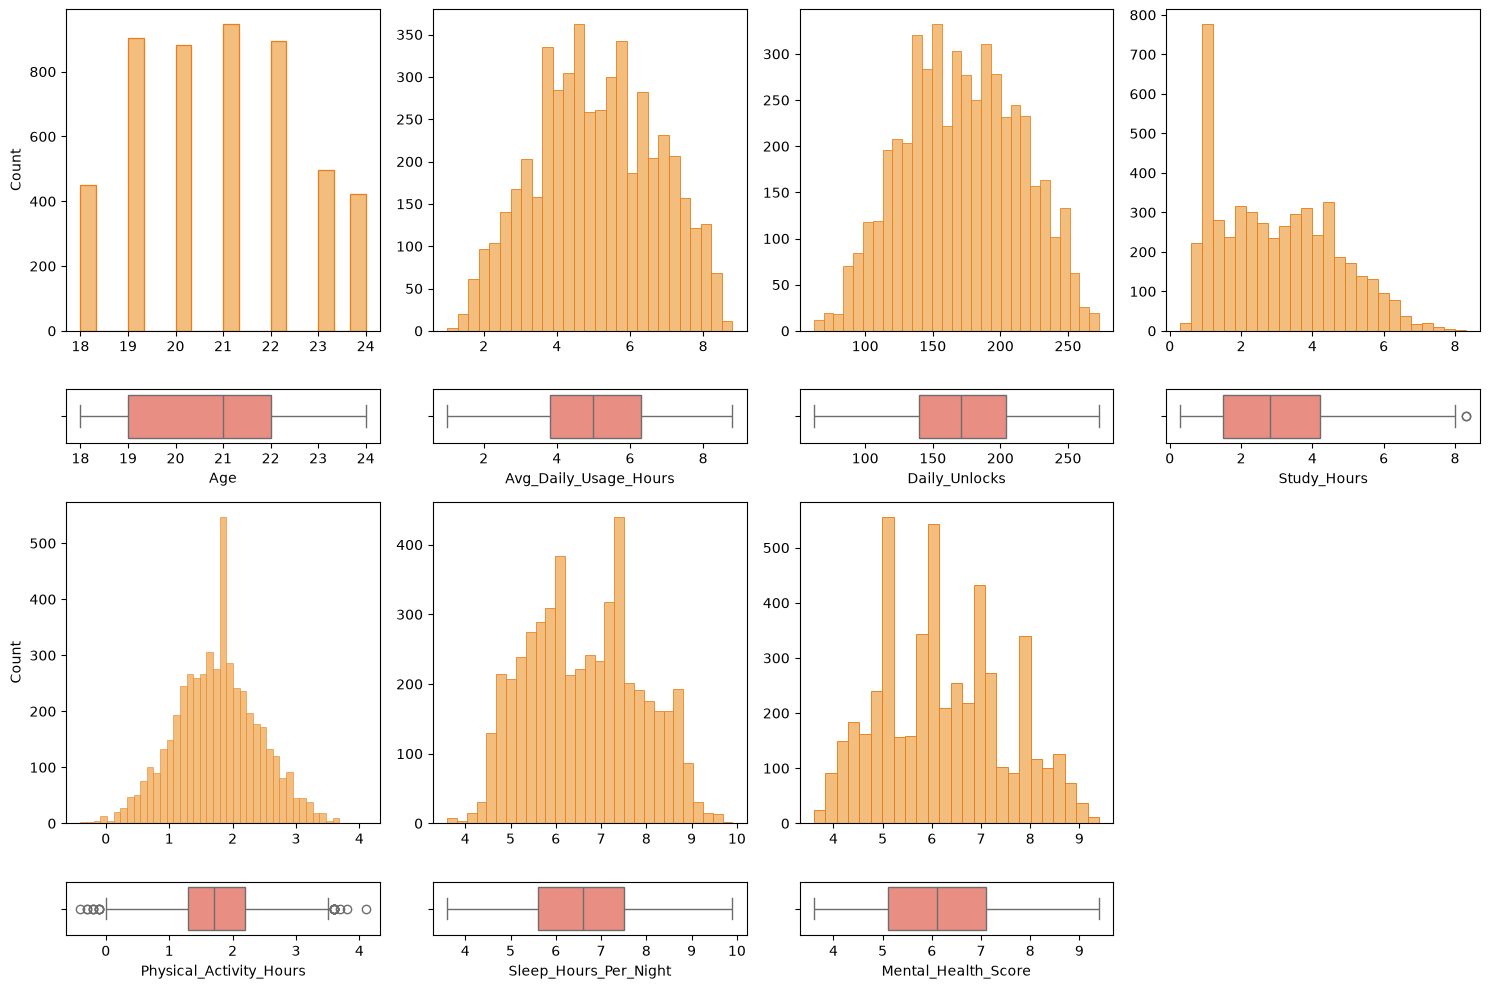

In [ ]:
fig, axis = plt.subplots(4, 4, figsize = (15, 10), gridspec_kw={'height_ratios': [6, 1, 6, 1]})

sns.histplot(ax = axis[0, 0], data = df, x = "Age", color="#F0A753", edgecolor="#E77F1D").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = df, x = "Age", color='salmon')
sns.histplot(ax = axis[0, 1], data = df, x = "Avg_Daily_Usage_Hours", color="#F0A753", edgecolor="#E77F1D").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df, x = "Avg_Daily_Usage_Hours", color='salmon')
sns.histplot(ax = axis[0, 2], data = df, x = "Daily_Unlocks", color="#F0A753", edgecolor="#E77F1D").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 2], data = df, x = "Daily_Unlocks", color='salmon')
sns.histplot(ax = axis[0, 3], data = df, x = "Study_Hours", color="#F0A753", edgecolor="#E77F1D").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 3], data = df, x = "Study_Hours", color='salmon')
sns.histplot(ax = axis[2, 0], data = df, x = "Physical_Activity_Hours", color="#F0A753", edgecolor="#E77F1D").set(xlabel = None)
sns.boxplot(ax = axis[3, 0], data = df, x = "Physical_Activity_Hours", color='salmon')
sns.histplot(ax = axis[2, 1], data = df, x = "Sleep_Hours_Per_Night", color="#F0A753", edgecolor="#E77F1D").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 1], data = df, x = "Sleep_Hours_Per_Night", color='salmon')
sns.histplot(ax = axis[2, 2], data = df, x = "Mental_Health_Score", color="#F0A753", edgecolor="#E77F1D").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 2], data = df, x = "Mental_Health_Score", color='salmon')

fig.delaxes(axis[2,3])
fig.delaxes(axis[3,3])

plt.tight_layout()

plt.show()

- El análisis de las distribuciones nos muestran patrones claros sobre el uso de tecnología, el tiempo de estudio y los indicadores de bienestar en una población de jóvenes estudiantes.

- El tiempo diario de pantalla (**'Avg_Daily_Usage_Hours'**) tiene una distribución simétrica con un eje central en las 5 horas, mientras que los desbloqueos diarios (**'Daily_Unlocks'**) se distribuyen de forma normal alrededor de 170 desbloqueos. Esto refleja un uso constante e intermitente del teléfono a lo largo del día.

- La población de estudiantes se concentra entre los 18 y 24 años, con una mediana de 21 años y mayor presencia en el rango de 19 a 22 años.

- En las horas de estudio (**'Study_Hours'**) podemos ver una asimetría positiva marcada a la derecha. La mayoría de las personas estudia entre 1 y 4 horas al día, con una alta tendencia hacia 1 hora y muy pocos casos dedican más de 6 horas promedio diarias.

- EN el hábito de actividad física (**'Physycal_Activity_Hours'**) refleja un comportamiento estable y simétrico con su centro cercano a 2 horas diarias, con una variabilidad baja y pocos valores atípicos.

- Las horas de sueño (**'Sleep_Hours_Per_Night'**) muestran una estructura bimodal con máximos principales alrededor de las 6 horas y las 7.5 horas, lo que sugiere que existen dos grupos diferenciados respecto a sus hábitos de descanso.

- La variable **'Mental_Health_Score'** se mueve entre 3.5 aprox. y casi 10 puntos, con una distribución multimodal que presenta varias concentraciones entre los 5 y 8 puntos, indicando percepciones de bienestar muy heterogéneas dentro del grupo.

- Los datos reflejan un perfil predominantemente universitario con una alta interacción digital y niveles moderados de estudio y actividad física, donde las diferencias más notables entre individuos estan en la calidad del descanso y la percepción de su salud mental.

### Paso 4 EDA: Análisis de variables multivariante

**Análisis categórico-categórico**

In [ ]:
df.columns

Index(['Age', 'Gender', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

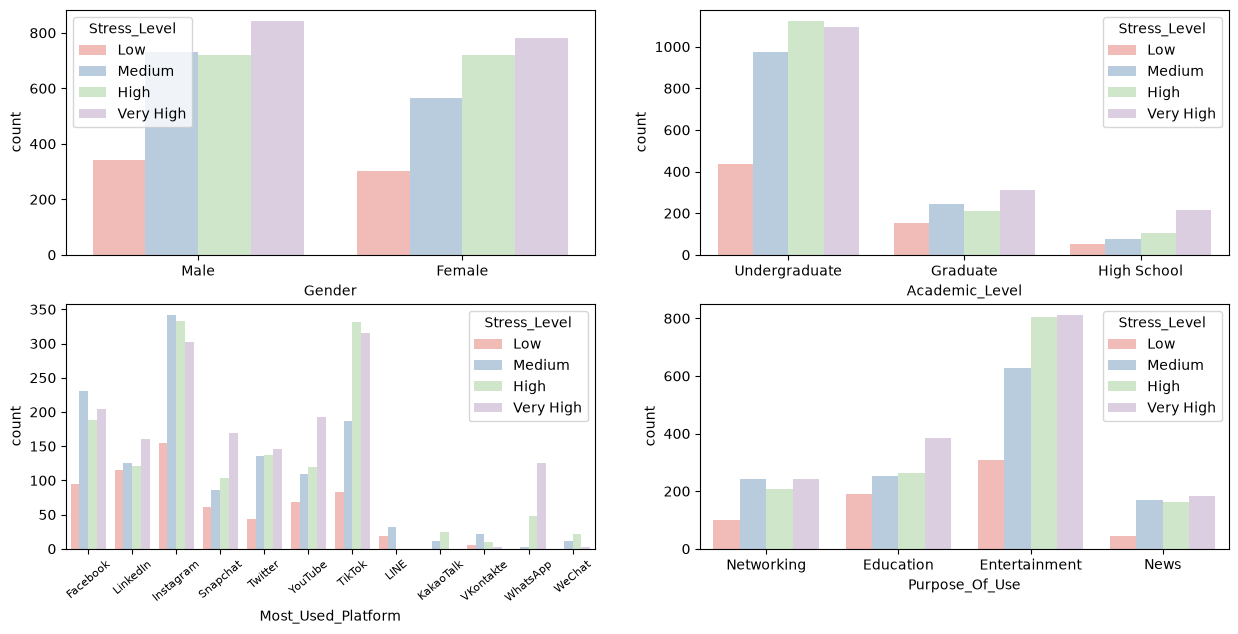

In [ ]:
fig, axis = plt.subplots(2, 2, figsize = (15, 7))

orden_stress = ['Low', 'Medium', 'High', 'Very High']

sns.countplot(ax = axis[0,0], data=df, x='Gender', hue='Stress_Level', hue_order=orden_stress, palette='Pastel1')
sns.countplot(ax = axis[0,1], data=df, x='Academic_Level', hue='Stress_Level', hue_order=orden_stress, palette='Pastel1')
sns.countplot(ax = axis[1,0], data=df, x='Most_Used_Platform', hue='Stress_Level', hue_order=orden_stress, palette='Pastel1').tick_params(axis='x', rotation=40, labelsize=8)
sns.countplot(ax = axis[1,1], data=df, x='Purpose_Of_Use', hue='Stress_Level', hue_order=orden_stress, palette='Pastel1')

plt.show()

- En relación al género de los estudiantes (**'Gender'**) podemos observar un patrón bien similar entre ellos, ya que tanto en hombres como en mujeres, la distribución de estrés sigue la misma tendencia ascendente, la minoría reporta estrés bajo (300 aprox.), mientras que la gran mayoría se concentra en niveles alto (sobre 700) y muy alto (800 aprox.). A partir de esta información, podemos inferir que el género no es un factor determinante en la variación del estrés.

- Con respecto al nivel académico de los estudiantes (**Academic_Level'**), vemos una concentración del volumen, ya que el nivel No Graduado (***'Undergraduate'***) acumula la gran mayoría de estudiantes, donde los niveles altos (***'High'***) y muy altos (***'Very High'***) de estrés superan los 1.000 individuos cada uno. También podemos ver en los tres niveles educativos: No Graduado (***'Undergraduate'***), Graduado (***'Graduate'***) y Secundaria (***'High School'***), la categoría muy alta es siempre la más numerosa en comparación con el estrés bajo (***'Low'***), lo que confirma una alta prevalencia de estrés en todos los niveles formativos.

- Pasando a las plataformas más usadas (**'Most_Used Platform'**), el gráfico nos muesta predominio de estrés elevado en TikTok e Instagram, ya que entre los estudiantes que tienen un uso principal de Instagram o TikTok, las barras de estrés alto (***'High'***) y muy alto (***'Very High'***) superan ampliamente a las de estrés bajo. En ambas RRSS recién mencionadas, más de 300 usuarios reportan niveles alto y muy alto en cada una, comparado con menos de 150 en nivel bajo en cada una. WhatsApp muestra una desproporción notable con la mayoría de sus usuarios concentrados en el nivel de estrés muy alto (100-150).

- Finalizando con el própósito de uso (**'Purpose_Of_Use'**), notamos el entretenimiento (***'Entertainment'***) en el uso de las redes como finalidad principal entre los estudiantes y registran los niveles más elevados de estrés, superando los 800 usuarios tanto en nivel alto (***'High'***) como en muy alto (***'Very High'***). Por otro lado, quienes usan las redes con fines de educación (***'Education'***) muestran una tendencia marcada hacia el estrés muy alto, mientras que en los que tienen por objetivo crear y/o mantener una red de contactos laboral (***'Networking'***) y los que tienen el fin de leer noticias (***'News'***), los niveles se distribuyen de forma más parecida entre los niveles medio, alto y muy alto.

Resumiendo, el estrés alto y muy alto predomina de forma transversal en todos los géneros y niveles educativos, pero se acentúa en estudiantes que consumen plataformas de contenido audiovisual/redes sociales (TikTok, Instagram) y en quienes usan la tecnología principalmente para entretenimiento o educación.

Dentro del análisis multivariante categórico-categórico tambien podemos hacer combinaciones de la clase con varias predictoras.

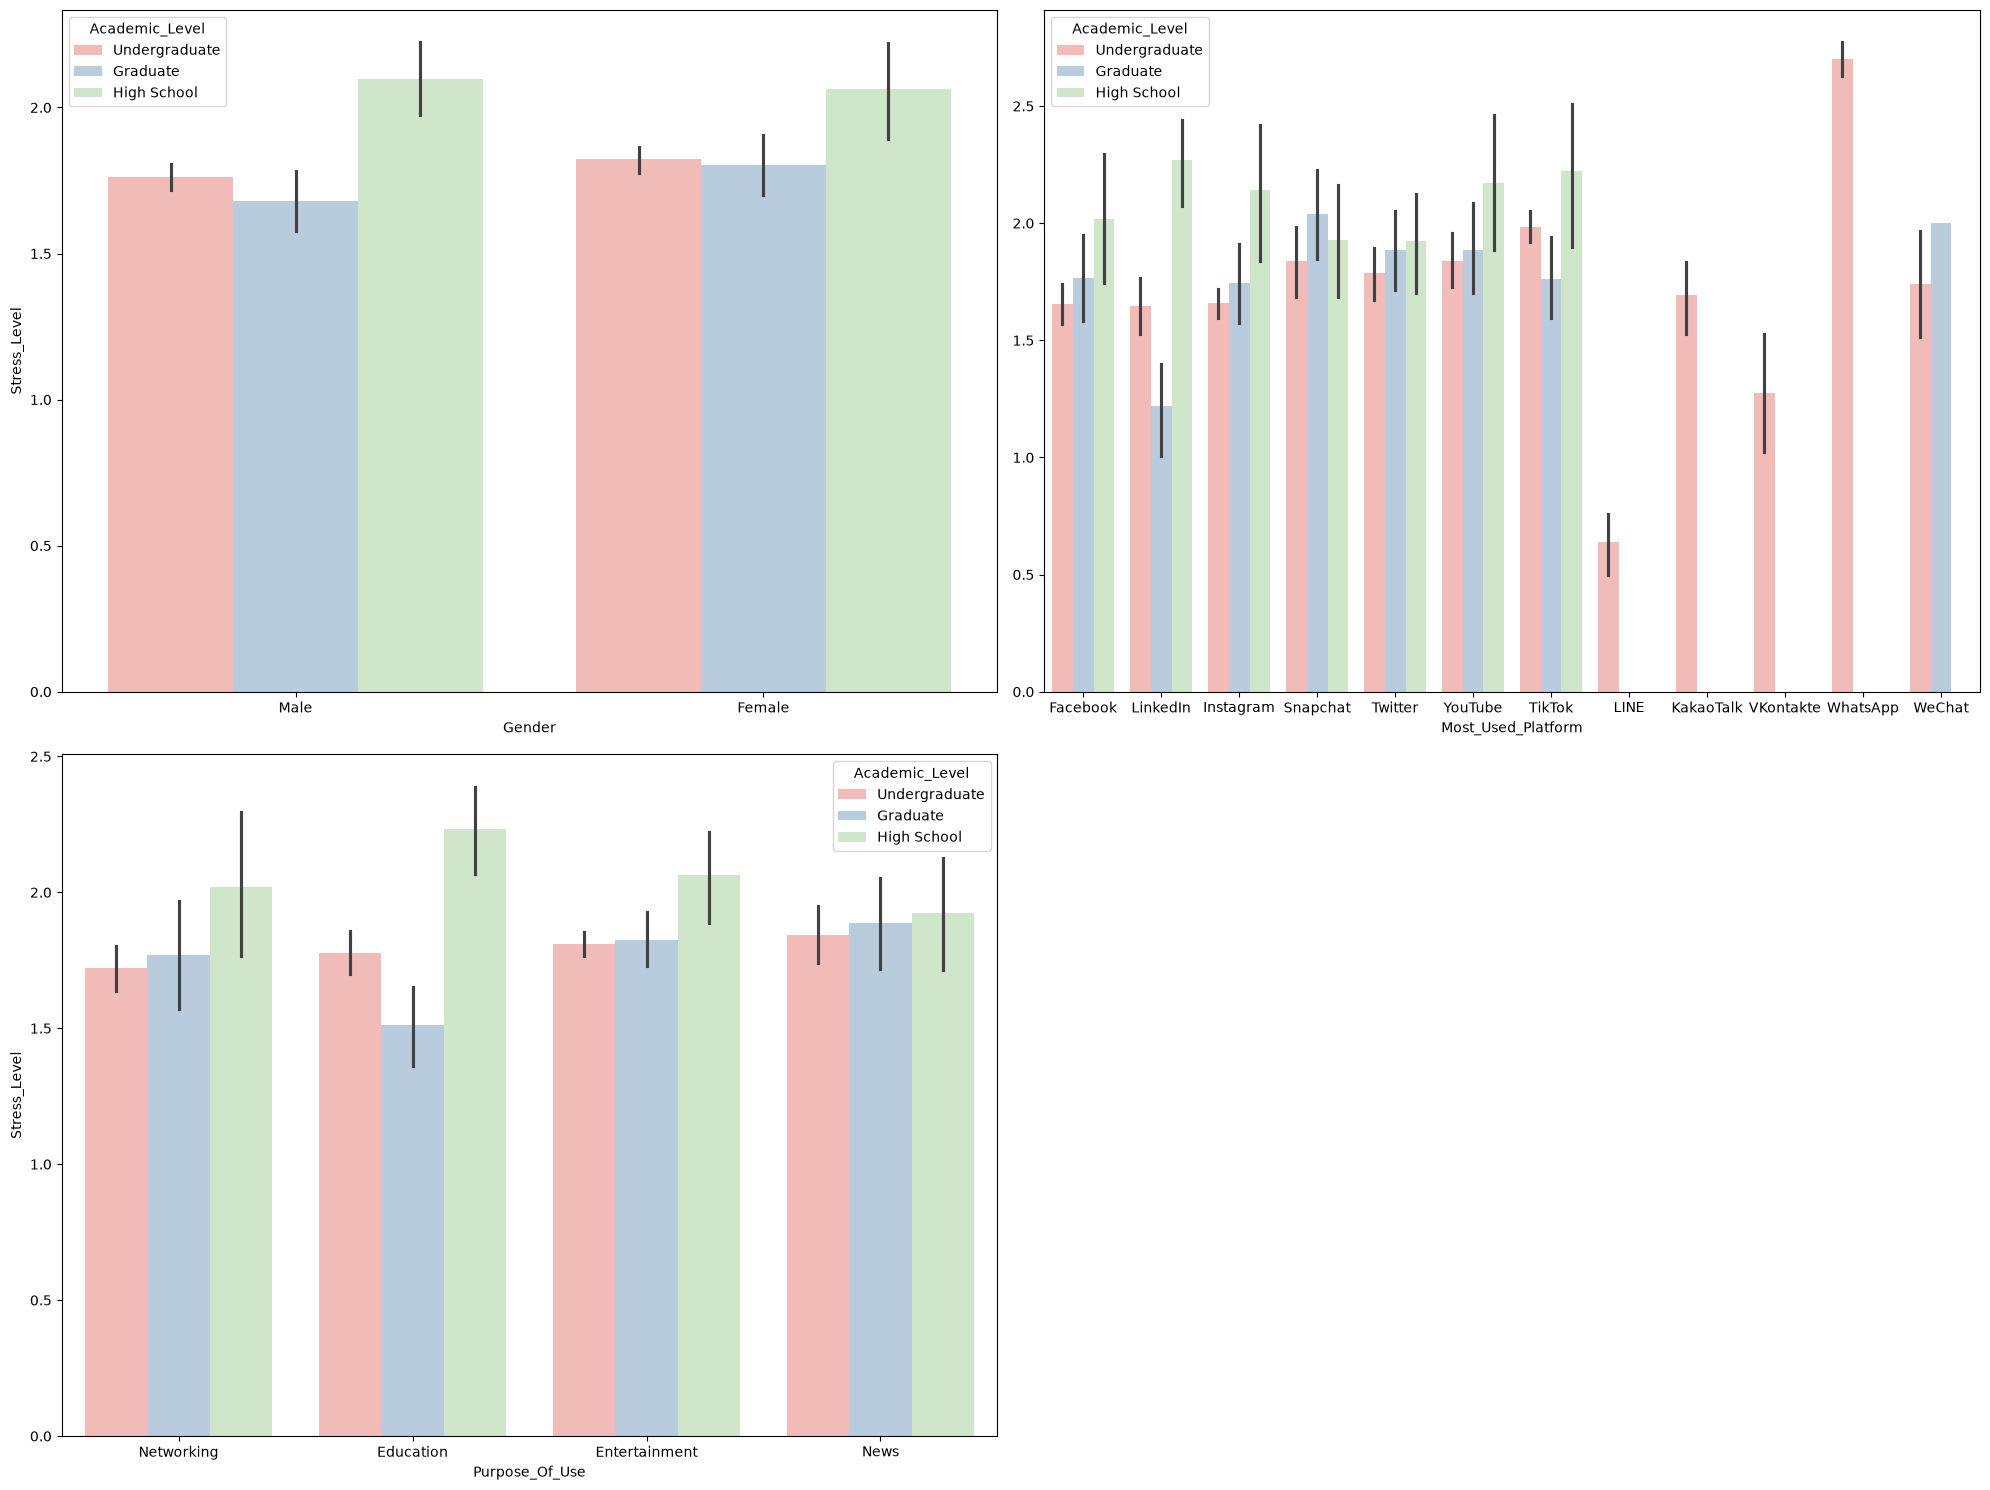

In [ ]:
fig, axis = plt.subplots(2, 2, figsize = (20, 15))

sns.barplot(ax = axis[0,0], data = df, x = 'Gender', y = 'Stress_Level', hue = 'Academic_Level', palette = 'Pastel1')
sns.barplot(ax = axis[0,1], data = df, x = 'Most_Used_Platform', y = 'Stress_Level', hue = 'Academic_Level', palette = 'Pastel1').set(ylabel = None)
sns.barplot(ax = axis[1,0], data = df, x = 'Purpose_Of_Use', y = 'Stress_Level', hue = 'Academic_Level', palette = 'Pastel1')

fig.delaxes(axis[1,1])

plt.tight_layout()

plt.show()

A simple vista podemos observar que los estudiantes de secundaria (***'High School'***) experimentan promedios de estrés más altos en la mayoría de escenarios, alcanzando sus máximos al usar las plataformas con fines educativos o consumir redes audiovisuales, mientras que en universitarios no graduados destacan los niveles de estrés asociados al uso intensivo de aplicaciones de mensajería como WhatsApp.

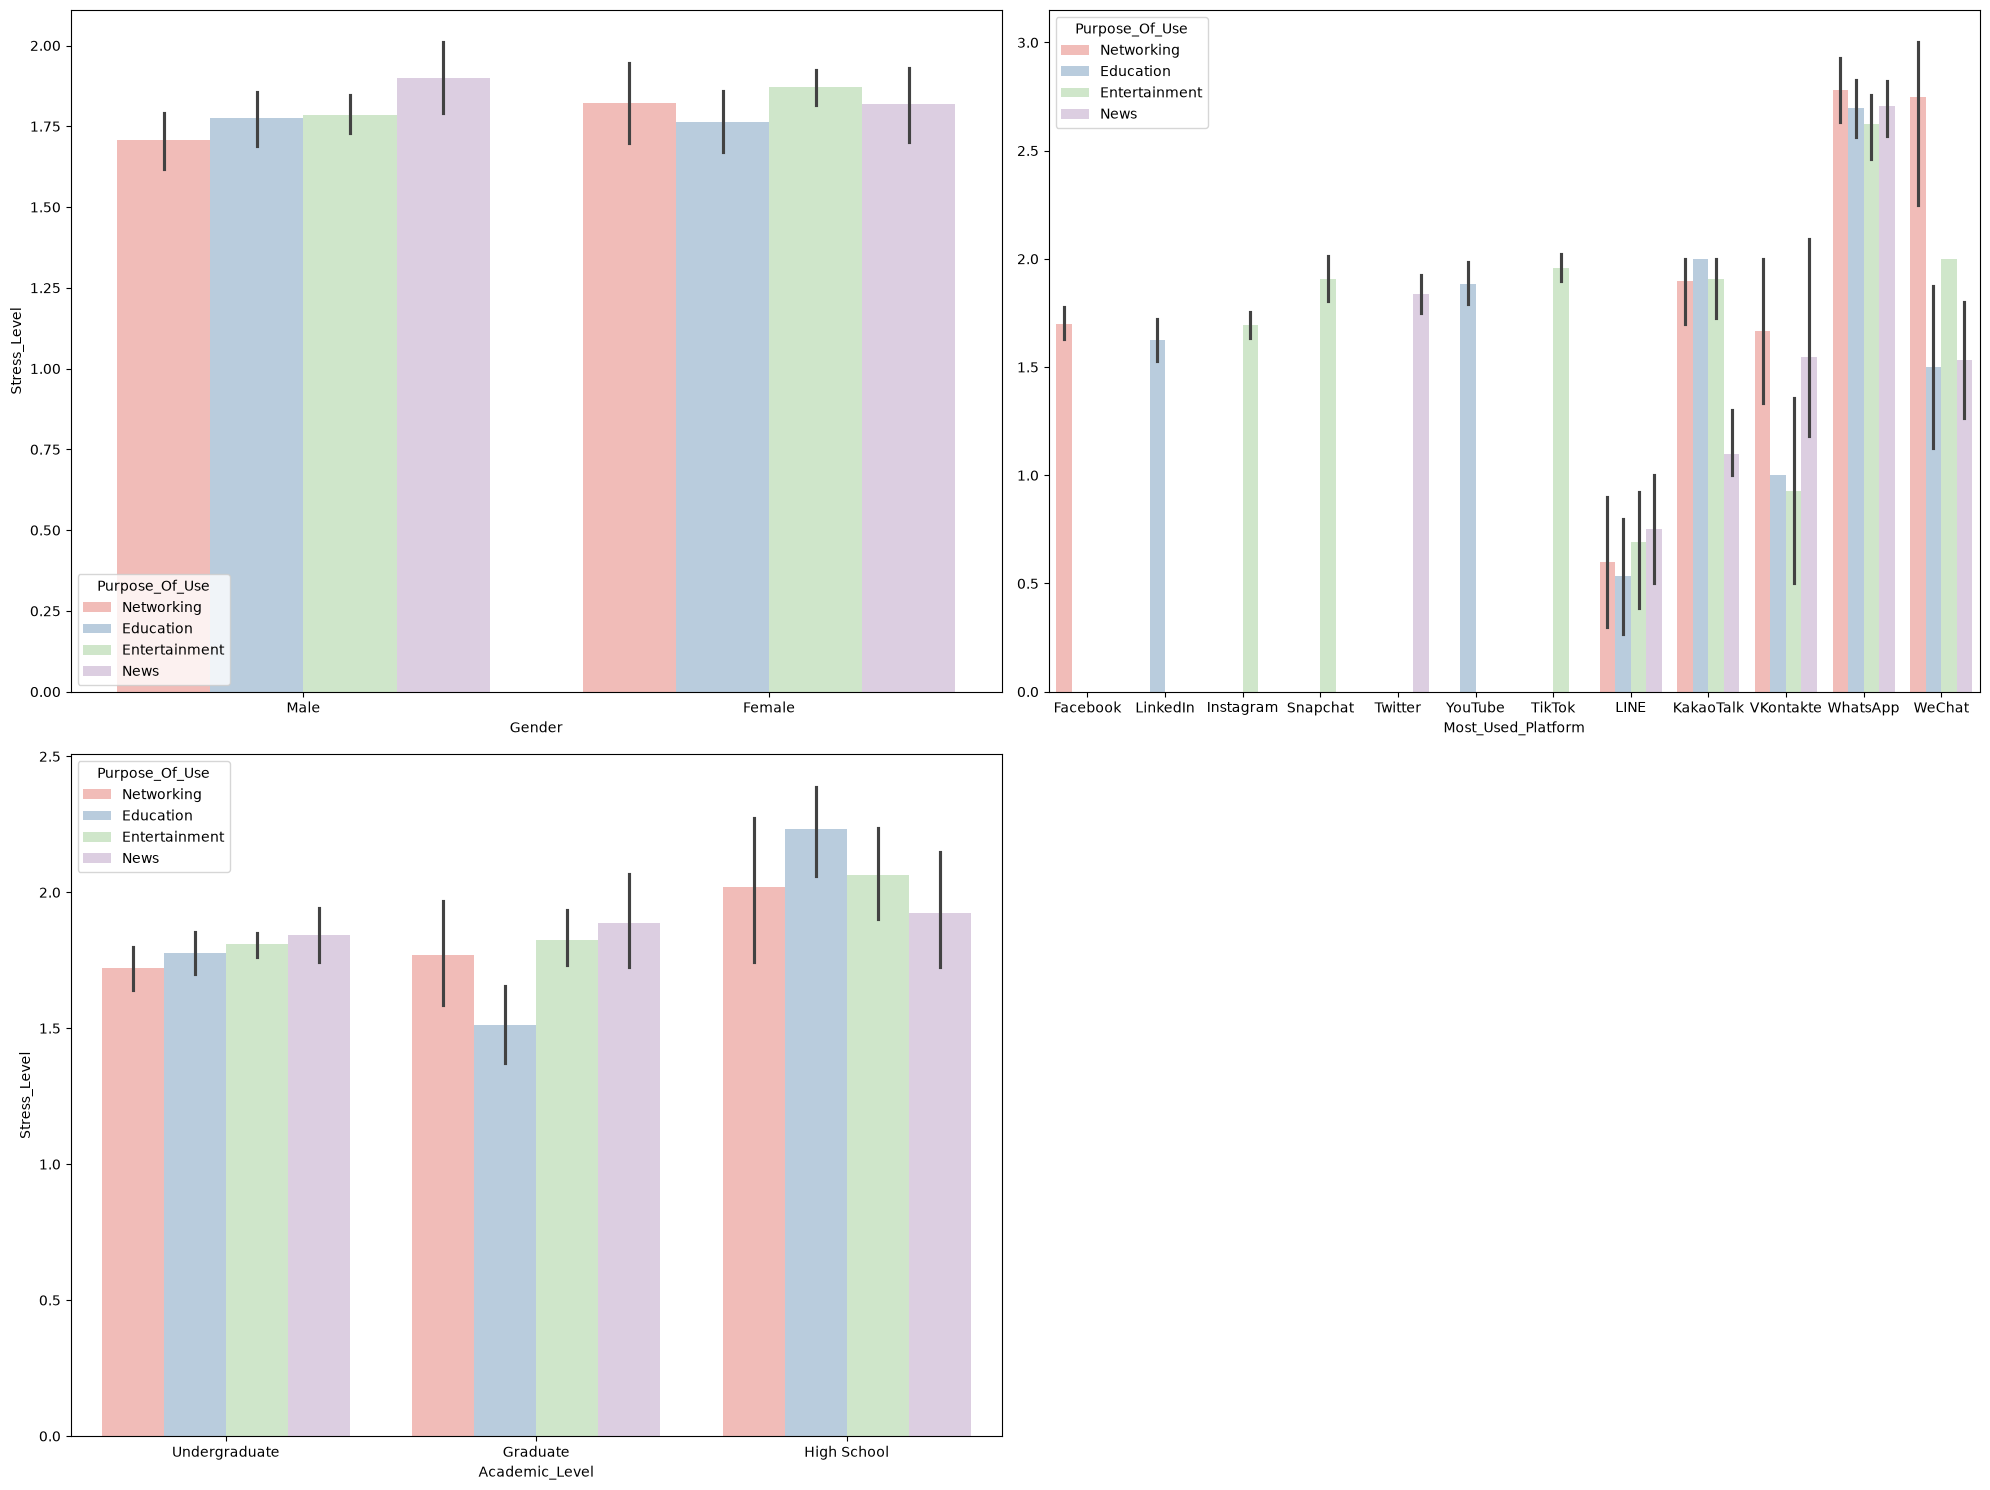

In [ ]:
fig, axis = plt.subplots(2, 2, figsize = (20, 15))

sns.barplot(ax = axis[0,0], data = df, x = 'Gender', y = 'Stress_Level', hue = 'Purpose_Of_Use', palette = 'Pastel1')
sns.barplot(ax = axis[0,1], data = df, x = 'Most_Used_Platform', y = 'Stress_Level', hue = 'Purpose_Of_Use', palette = 'Pastel1').set(ylabel = None)
sns.barplot(ax = axis[1,0], data = df, x = 'Academic_Level', y = 'Stress_Level', hue = 'Purpose_Of_Use', palette = 'Pastel1')

fig.delaxes(axis[1,1])

plt.tight_layout()

plt.show()

El impacto del propósito de uso en el estrés varía significativamente según la etapa académica (siendo la educación muy estresante en secundaria pero atenuante cuando ya esta graduado) y está condicionado por la plataforma utilizada, donde WhatsApp sobresale como el canal con mayor nivel medio de estrés.

Ahora continuaremos con el análisis de correlaciones.


In [ ]:
df.columns

Index(['Age', 'Gender', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

In [ ]:
from scipy.stats import chi2_contingency

#Género vs Nivel de estrés
tabla_genero = pd.crosstab(df['Gender'], df['Stress_Level'])
print('Género vs Nivel de estrés')
print(tabla_genero, "\n")

chi2, p, dof, expected = chi2_contingency(tabla_genero)
print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}\n")

if p < 0.05:
    print("Existe una relación significativa entre género y nivel de estrés.")
    print("La tabla muestra que proporcionalmente los hombres experimentan más estrés que las mujeres.\n")
else:
    print("No se observa una relación estadísticamente significativa.\n")
print("°°°°°°\n")
    
#Nivel Académico vs Nivel de estrés
tabla_nivel_academico = pd.crosstab(df['Academic_Level'], df['Stress_Level'])
print('Nivel Académico vs Nivel de estrés')
print(tabla_nivel_academico, "\n")

chi2, p, dof, expected = chi2_contingency(tabla_nivel_academico)
print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}\n")

if p < 0.05:
    print("El nivel académico del estudiante está asociado con el nivel de estrés.")
    print("Los estudiantes universitarios no graduados tienden a experimentar más estrés.\n")
else:
    print("No se observa una relación estadísticamente significativa.\n")
print("°°°°°°\n")

#Plataforma más usada vs Nivel de estrés
tabla_plataforma = pd.crosstab(df['Most_Used_Platform'], df['Stress_Level'])
print('Plataforma más usada vs Nivel de estrés')
print(tabla_plataforma, "\n")

chi2, p, dof, expected = chi2_contingency(tabla_plataforma)
print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}\n")

if p < 0.05:
    print("La plataforma más usada tiene relación con el nivel de estrés.")
    print("Algunas plataformas muestran mayor proporción de estudiantes con alto nivel de estrés.\n")
else:
    print("No se observa una relación estadísticamente significativa.\n")
print("°°°°°°\n")

#Propósito de Uso vs Nivel de estrés
tabla_proposito = pd.crosstab(df['Purpose_Of_Use'], df['Stress_Level'])
print('Propósito de Uso vs Nivel de estrés')
print(tabla_proposito, "\n")

chi2, p, dof, expected = chi2_contingency(tabla_proposito)
print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}\n")

if p < 0.05:
    print("El propósitos de uso tiene relación con el nivel de estrés.")
    print("Algunos propósitos muestran mayor proporción de estudiantes con alto nivel de estrés.\n")
else:
    print("No se observa una relación estadísticamente significativa.\n")



Género vs Nivel de estrés
Stress_Level  High  Low  Medium  Very High
Gender                                    
Female         719  301     564        780
Male           720  342     731        841 

Chi2 = 11.90, p-value = 0.0078

Existe una relación significativa entre género y nivel de estrés.
La tabla muestra que proporcionalmente los hombres experimentan más estrés que las mujeres.

°°°°°°

Nivel Académico vs Nivel de estrés
Stress_Level    High  Low  Medium  Very High
Academic_Level                              
Graduate         211  154     243        310
High School      107   51      76        216
Undergraduate   1121  438     976       1095 

Chi2 = 89.19, p-value = 0.0000

El nivel académico del estudiante está asociado con el nivel de estrés.
Los estudiantes universitarios no graduados tienden a experimentar más estrés.

°°°°°°

Plataforma más usada vs Nivel de estrés
Stress_Level        High  Low  Medium  Very High
Most_Used_Platform                              
Facebook 

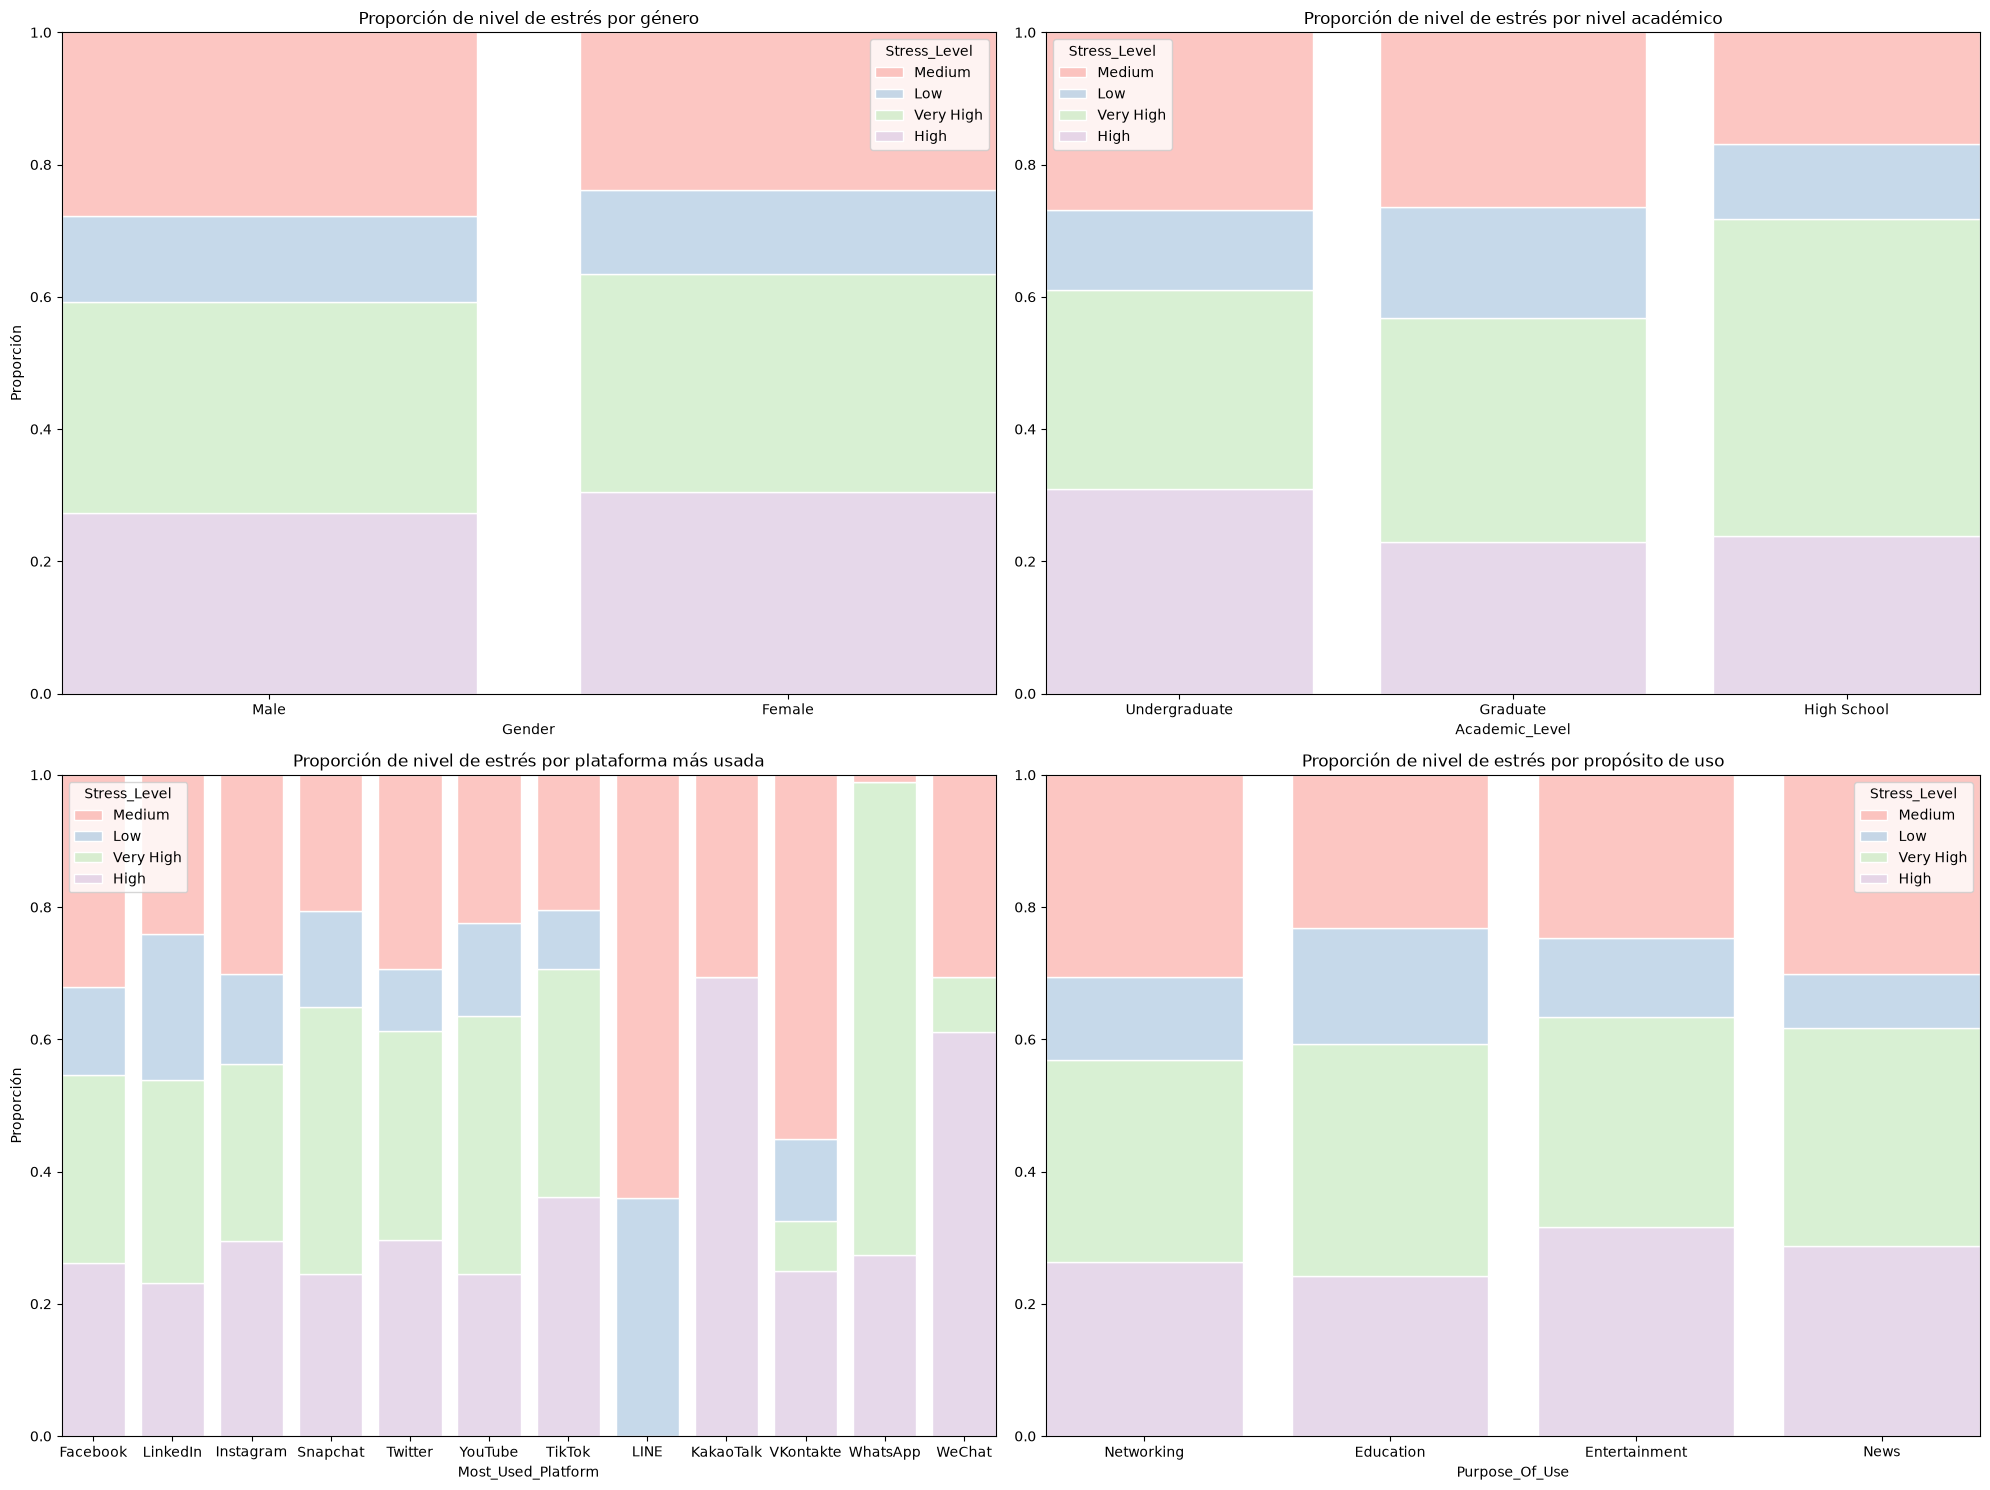

In [ ]:
fig, axis = plt.subplots(2, 2, figsize = (20, 15))


#Visualización: proporción de nivel de estrés por género
sns.histplot(ax=axis[0,0], data=df, x='Gender', hue='Stress_Level', multiple='fill', shrink=0.8, palette='Pastel1', edgecolor='white').set_title("Proporción de nivel de estrés por género")
axis[0,0].set(ylabel = "Proporción")
#Visualización: proporción de nivel de estrés por nivel académico
sns.histplot(ax=axis[0,1], data=df, x='Academic_Level', hue='Stress_Level', multiple='fill', shrink=0.8, palette='Pastel1', edgecolor='white').set_title("Proporción de nivel de estrés por nivel académico")
axis[0,1].set(ylabel = None)
#Visualización: proporción de nivel de estrés por plataforma más usada
sns.histplot(ax=axis[1,0], data=df, x='Most_Used_Platform', hue='Stress_Level', multiple='fill', shrink=0.8, palette='Pastel1', edgecolor='white').set_title("Proporción de nivel de estrés por plataforma más usada")
axis[1,0].set(ylabel = "Proporción")
#Visualización: proporción de nivel de estrés por propósito de uso
sns.histplot(ax=axis[1,1], data=df, x='Purpose_Of_Use', hue='Stress_Level', multiple='fill', shrink=0.8, palette='Pastel1', edgecolor='white').set_title("Proporción de nivel de estrés por propósito de uso")
axis[1,1].set(ylabel = None)

plt.tight_layout()
plt.show()



El análisis de las tablas de contingencia y el test Chi-cuadrado nos muestra que la plataforma más usada (**'Most_Used_Platform'**) es la variable con mayor fuerza de asociación con el estrés, lo que indica que el tipo de plataforma digital que utiliza un estudiante está fuertemente vinculado a su categoría de estrés. El nivel académico (**'Academic_Level'**) ocupa el segundo lugar en importancia mostrándonos una asociación bastante más baja que la anterior, destacando que los estudiantes universitarios no graduados concentran los mayores niveles de estrés en comparación con otros niveles. En el caso del propósito de uso (**'Purpose_Of_Use'**) presenta una relación significativa pero aun más débil que el nivel académico, es decir, el motivo por el cual utilizan la tecnología influye en el estrés, especialmente en quienes buscan entretenimiento o educación. Finalizando con el género (**'Gender'**), es la variable con menor fuerza de asociación lo que nos indica que el género del estudiante esta débilmente vinculada con el nivel de estrés.

**Análisis numérico-numérico**

Primero transformaremos nuestra variable objetivo a una variable numérica para sumarla en este paso.

In [ ]:
print(df["Stress_Level"].unique())

<ArrowStringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str


In [ ]:
df["Stress_Level"] = df["Stress_Level"].map({
    'Low': 0,
    'Medium': 1,
    'High': 2,
    'Very High': 3
})

In [ ]:
df.head()

,Age,Gender,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,1,6.8
1,23,Female,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,0,7.6
2,22,Male,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,1,7.0
3,18,Male,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,3,5.3
4,24,Female,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,3,4.4


Ahora que nuestra objetivo ya es numérica, iniciamos nuestro análisis

In [ ]:
df.columns

Index(['Age', 'Gender', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

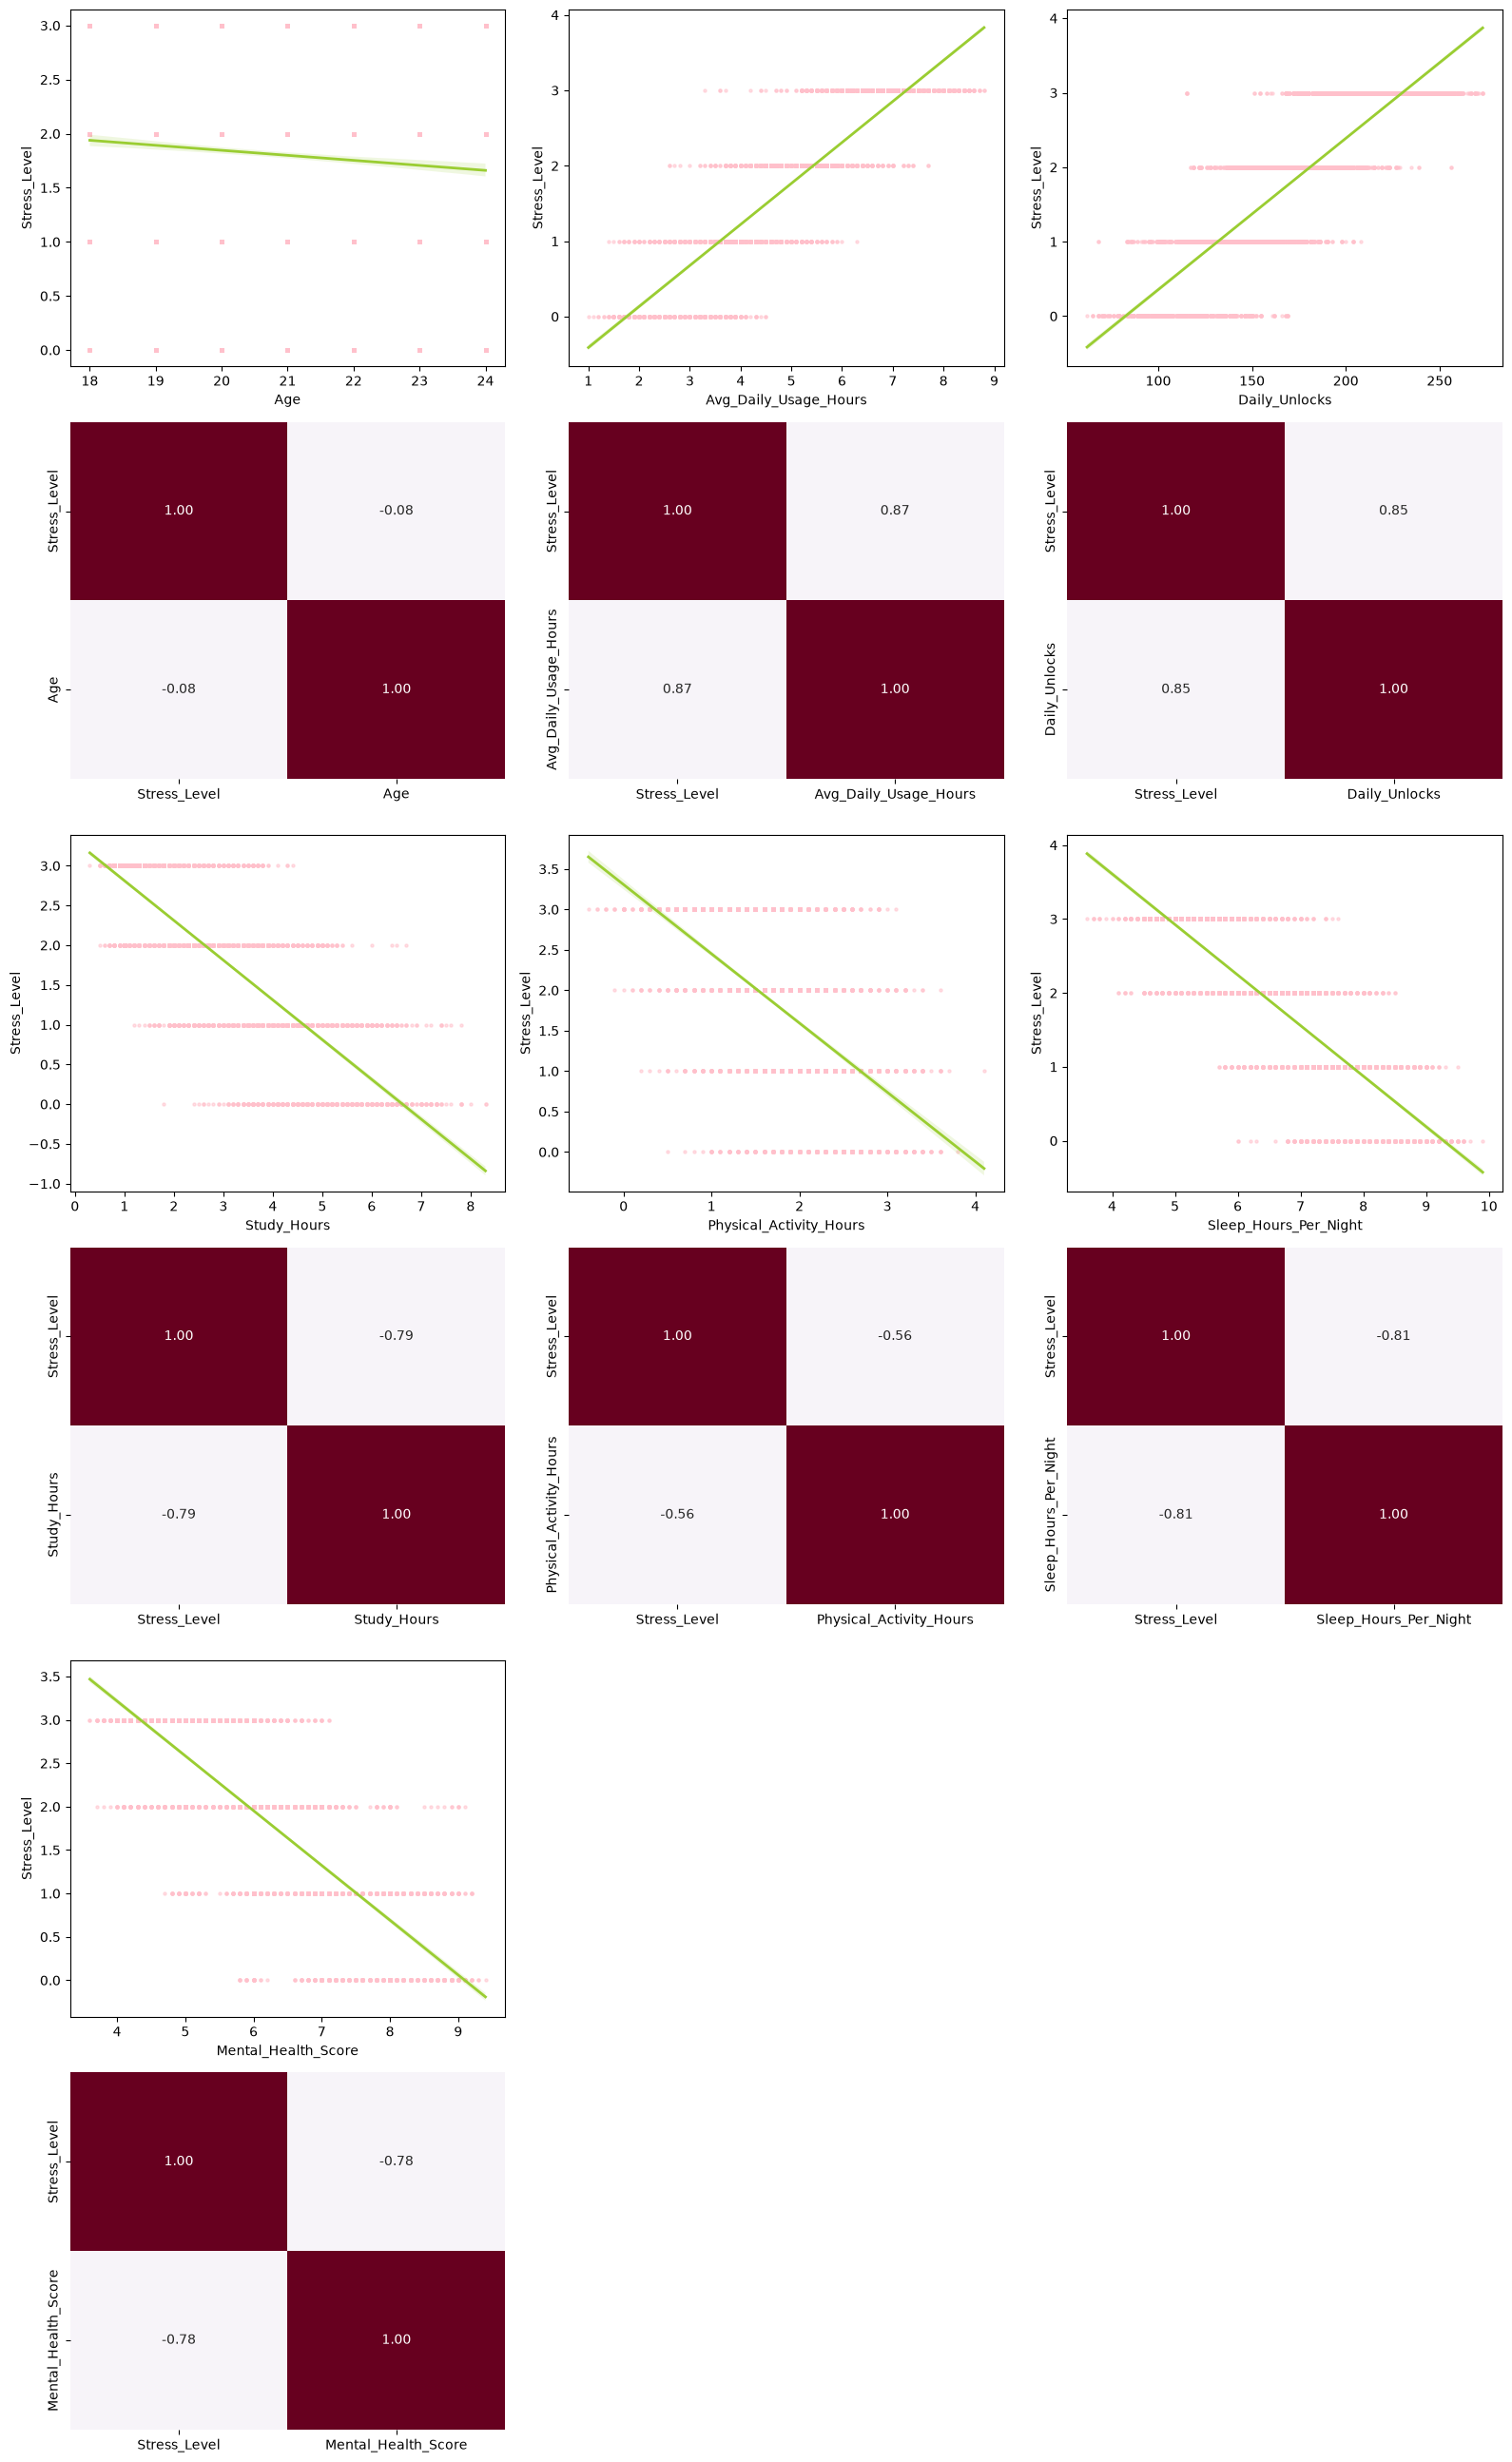

In [ ]:
fig, axis = plt.subplots(6,3, figsize=(16,26))

sns.regplot(ax = axis[0,0], data = df, x = "Age", y = "Stress_Level", scatter_kws = {'s': 5 ,'alpha':0.5, 'color':'pink'}, line_kws = {'color':'yellowgreen', 'linewidth': 2})
sns.heatmap(df[["Stress_Level","Age"]].corr(), annot=True, fmt = '.2f', ax = axis[1,0], cmap='PuRd', cbar=False)

sns.regplot(ax = axis[0,1], data = df, x = "Avg_Daily_Usage_Hours", y = "Stress_Level", scatter_kws = {'s': 5 ,'alpha':0.5, 'color':'pink'}, line_kws = {'color':'yellowgreen', 'linewidth': 2})
sns.heatmap(df[["Stress_Level","Avg_Daily_Usage_Hours"]].corr(), annot=True, fmt = '.2f', ax = axis[1,1], cmap='PuRd', cbar=False)

sns.regplot(ax = axis[0,2], data = df, x = "Daily_Unlocks", y = "Stress_Level", scatter_kws = {'s': 5 ,'alpha':0.5, 'color':'pink'}, line_kws = {'color':'yellowgreen', 'linewidth': 2})
sns.heatmap(df[["Stress_Level","Daily_Unlocks"]].corr(), annot=True, fmt = '.2f', ax = axis[1,2], cmap='PuRd', cbar=False)

sns.regplot(ax = axis[2,0], data = df, x = "Study_Hours", y = "Stress_Level", scatter_kws = {'s': 5 ,'alpha':0.5, 'color':'pink'}, line_kws = {'color':'yellowgreen', 'linewidth': 2})
sns.heatmap(df[["Stress_Level","Study_Hours"]].corr(), annot=True, fmt = '.2f', ax = axis[3,0], cmap='PuRd', cbar=False)

sns.regplot(ax = axis[2,1], data = df, x = "Physical_Activity_Hours", y = "Stress_Level", scatter_kws = {'s': 5 ,'alpha':0.5, 'color':'pink'}, line_kws = {'color':'yellowgreen', 'linewidth': 2})
sns.heatmap(df[["Stress_Level","Physical_Activity_Hours"]].corr(), annot=True, fmt = '.2f', ax = axis[3,1], cmap='PuRd', cbar=False)

sns.regplot(ax = axis[2,2], data = df, x = "Sleep_Hours_Per_Night", y = "Stress_Level", scatter_kws = {'s': 5 ,'alpha':0.5, 'color':'pink'}, line_kws = {'color':'yellowgreen', 'linewidth': 2})
sns.heatmap(df[["Stress_Level","Sleep_Hours_Per_Night"]].corr(), annot=True, fmt = '.2f', ax = axis[3,2], cmap='PuRd', cbar=False)

sns.regplot(ax = axis[4,0], data = df, x = "Mental_Health_Score", y = "Stress_Level", scatter_kws = {'s': 5 ,'alpha':0.5, 'color':'pink'}, line_kws = {'color':'yellowgreen', 'linewidth': 2})
sns.heatmap(df[["Stress_Level","Mental_Health_Score"]].corr(), annot=True,fmt = '.2f', ax = axis[5,0], cmap='PuRd', cbar=False)

fig.delaxes(axis[4,1])
fig.delaxes(axis[4,2])
fig.delaxes(axis[5,1])
fig.delaxes(axis[5,2])
            
plt.tight_layout()

plt.show()

Los diagramas de correlación permiten identificar la dirección y la intensidad de correlación entre las variables predictoras y el nivel estrés (**'Stress_Level'**). Estas correlaciones sirven como análisis exploratorio previo al modelo, permitiendo detectar variables potencialmente relevantes y posibles problemas de multicolinealidad entre las predictoras.

Analicemos primero los gráficos que nos muestran una correlación **POSITIVA**, o sea, que aumentan el Estrés.

- Uso diario del teléfono (**'Avg_Daily_Usage_Hours'**): Tiene una correlación positiva muy fuerte (0.87). Es decir, a mayor cantidad de horas en pantalla, mayor es el nivel de estrés registrado.

- Desbloqueos diarios (**'Daily_Unlocks'**): Muestra una correlación positiva casi tan fuerte como el anterior (0.85), entonces podemos inferir que la frecuencia de interacción con el dispositivo está altamente relacionada a niveles más altos de estrés.

Sigamos con el análisis los gráficos donde vemos una correlación **NEGATIVA**, o sea reducen el estrés.

- Horas de descanso (**'Sleep_Hours_Per_Night'**): Podemos observar una correlación negativa intensa (-0.81). Lo que nos indica que dormir más horas por noche se asocia directamente con una reducción significativa en los niveles de estrés.

- Horas de estudio (**'Study_Hours'**): Posee una correlación negativa alta (-0.79), sugiriendo que un mayor tiempo dedicado al estudio se vincula con menores niveles de estrés percibido.

- Salud mental (**'Mental_Health_Score'**): Vemos una relación inversa considerable (-0.78). Con lo que podemos inferir que un mejor puntaje en la evaluación de salud mental se traduce en niveles considerablemente más bajos de estrés.

- Actividad física (**'Physical_Activity_Hours'**: Tiene una correlación negativa moderada (-0.56), reflejando que cuando los estudiantes realizan ejercicio, les contribuye moderadamente a atenuar el estrés.

También tenemos algunos gráficos que nos muestran una falta de relación.

- Edad (**'Age'**): Vemos una correlación prácticamente nula (-0.08), es decir, la edad de los participantes no influye en la variabilidad del nivel de estrés dentro de este grupo de estudiantes.


En resumen, el estrés en este conjunto de datos está fuertemente impulsado por el uso intensivo y repetitivo de dispositivos móviles, mientras que el descanso adecuado, los hábitos de estudio y la actividad física actúan como factores reguladores clave para reducirlo..

Finalmente, para cerrar el estudio multivariante, queda analizar la relación entre las variables categóricas y las numéricas.

**Análisis numérico-categórico**

- Correlación únicamente entre variables numéricas (Pearson), para ver relaciones lineales entre continuas.

In [ ]:
df.info()